In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xarray as xr
import os
import re
import dask as da
from dask.diagnostics import ProgressBar
from pycontrails.core import GeoVectorDataset
from pycontrails.models.gpat.pp_gpat import mc_test, boxm_test
from pycontrails.models.gpat.pp_gpat import GPATPostProcessor

In [2]:
outputs_dir = "/projects/Impact_of_aviation_on_climate/Kieran2024/outputs/duds/" #
#outputs_dir = f"{os.getcwd()}/outputs/"

In [3]:
# Filter criteria
criteria = {
        # "n_ac": 3,
        # "rt_fl": (pd.Timedelta(minutes=30), pd.Timedelta(hours=2)),
        # "date_created": (pd.Timestamp("2024-11-16"), pd.Timestamp("2024-11-17")),
        "job_id": ["sensitivity"],
    }

In [4]:
pp_gpat = GPATPostProcessor(outputs_dir, criteria)
pp_gpat.filtered_df


,t0_fl,rt_fl,ts_fl,ac_type,fl0_speed,fl0_heading,fl0_coords0,sep_dist,n_ac,dt_integration,...,gen_outputs_proc,traj_gen,gen_met,bg_chem,ac_perf,emissions,sim_plumes,plume_to_grid,run_cc,run_boxm
job_id,,,,,,,,,,,,,,,,,,,,,
sensitivity_NA_3_4000_0_6_0.01_0.05,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,90.0,"(47.5, -32.9, 12500)","(4000.0, 0.0, 0.0)",3,0 days 00:02:00,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sensitivity_locs_US_1_2022-01-01T12_00_00,2022-01-01 12:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,90.0,"(37.5, -96.9, 11500.0)","(1000.0, 0.0, 0.0)",1,0 days 00:02:00,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sensitivity_locs_NA_1_2022-07-01T12_00_00,2022-07-01 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,90.0,"(47.5, -32.9, 12500.0)","(1000.0, 0.0, 0.0)",1,0 days 00:02:00,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sensitivity_NA_10_3000_0_6_0.01_0.05,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,90.0,"(47.5, -32.9, 12500)","(3000.0, 0.0, 0.0)",10,0 days 00:02:00,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sensitivity_NA_2_100_0_6_0.01_0.05,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,90.0,"(47.5, -32.9, 12500)","(100.0, 0.0, 0.0)",2,0 days 00:02:00,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sensitivity_NA_2_3000_0_6_0.01_0.05,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,90.0,"(47.5, -32.9, 12500)","(3000.0, 0.0, 0.0)",2,0 days 00:02:00,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sensitivity_NA_5_4000_0_6_0.01_0.05,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,90.0,"(47.5, -32.9, 12500)","(4000.0, 0.0, 0.0)",5,0 days 00:02:00,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sensitivity_NA_5_100_0_6_0.01_0.05,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,90.0,"(47.5, -32.9, 12500)","(100.0, 0.0, 0.0)",5,0 days 00:02:00,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sensitivity_NA_2_500_0_6_0.01_0.05,2022-01-20 13:00:00,0 days 01:00:00,0 days 00:02:00,A320,100.0,90.0,"(47.5, -32.9, 12500)","(500.0, 0.0, 0.0)",2,0 days 00:02:00,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Create dicts to hold all necessary data (but no more)
fl_df_dict = {}
for job_id in pp_gpat.job_ids:
    fl_df_dict[job_id] = pp_gpat.load_fl_df(job_id)

pl_df_dict = {}
for job_id in pp_gpat.job_ids:
    pl_df_dict[job_id] = pp_gpat.load_pl_df(job_id)

Loaded flight data for sensitivity_NA_3_4000_0_6_0.01_0.05
Loaded flight data for sensitivity_locs_US_1_2022-01-01T12_00_00
Loaded flight data for sensitivity_locs_NA_1_2022-07-01T12_00_00
Loaded flight data for sensitivity_NA_10_3000_0_6_0.01_0.05
Loaded flight data for sensitivity_NA_2_100_0_6_0.01_0.05
Loaded flight data for sensitivity_NA_2_3000_0_6_0.01_0.05
Loaded flight data for sensitivity_NA_5_4000_0_6_0.01_0.05
Loaded flight data for sensitivity_NA_5_100_0_6_0.01_0.05
Loaded flight data for sensitivity_NA_2_500_0_6_0.01_0.05
Loaded flight data for sensitivity_NA_2_2000_0_6_0.01_0.05
Loaded flight data for sensitivity_NA_5_2000_0_6_0.01_0.05
Loaded flight data for sensitivity_NA_5_3000_0_6_0.01_0.05
Loaded flight data for sensitivity_NA_3_2000_0_6_0.01_0.05
Loaded flight data for sensitivity_NA_5_5000_0_6_0.01_0.05
Loaded flight data for sensitivity_locs_EU_5_2022-12-01T12_00_00
Loaded flight data for sensitivity_NA_3_3000_0_6_0.01_0.05
Loaded flight data for sensitivity_NA_3_

In [6]:
# Initialize the dictionary
chem_ds_dict = {}

# Load the data
for job_id in pp_gpat.job_ids:
    chem_ds_dict[job_id] = pp_gpat.load_chem_ds(job_id, 1000)

/user/home/kt16229/BOXM/scratch/miniconda3/envs/contrails/lib/python3.12/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


Loaded chem ds for sensitivity_NA_3_4000_0_6_0.01_0.05
Loaded chem ds for sensitivity_locs_US_1_2022-01-01T12_00_00
Loaded chem ds for sensitivity_locs_NA_1_2022-07-01T12_00_00
Loaded chem ds for sensitivity_NA_10_3000_0_6_0.01_0.05
Loaded chem ds for sensitivity_NA_2_100_0_6_0.01_0.05
Loaded chem ds for sensitivity_NA_2_3000_0_6_0.01_0.05
Loaded chem ds for sensitivity_NA_5_4000_0_6_0.01_0.05
Loaded chem ds for sensitivity_NA_5_100_0_6_0.01_0.05
Loaded chem ds for sensitivity_NA_2_500_0_6_0.01_0.05
Loaded chem ds for sensitivity_NA_2_2000_0_6_0.01_0.05
Loaded chem ds for sensitivity_NA_5_2000_0_6_0.01_0.05
Loaded chem ds for sensitivity_NA_5_3000_0_6_0.01_0.05
Loaded chem ds for sensitivity_NA_3_2000_0_6_0.01_0.05
Loaded chem ds for sensitivity_NA_5_5000_0_6_0.01_0.05
Loaded chem ds for sensitivity_locs_EU_5_2022-12-01T12_00_00
Loaded chem ds for sensitivity_NA_3_3000_0_6_0.01_0.05
Loaded chem ds for sensitivity_NA_3_5000_0_6_0.01_0.05
Loaded chem ds for sensitivity_locs_SA_5_2022-01-

In [14]:
job_id = "sensitivity_NA_10_5000_0_6_0.01_0.05"

params = pp_gpat.filtered_df.loc[job_id]
fl_df = fl_df_dict[job_id]
pl_df = pl_df_dict[job_id]
chem_ds = chem_ds_dict[job_id].isel(job_id=0).compute()

#chem_ds["emi"].sel(emi_species="NO").sum(dim=["longitude", "latitude"]).values


In [ ]:
# # bg run conc time series plots
# fig, ax = plt.subplots(4, 2, figsize=(10, 10))

# params = pp_gpat.filtered_df.loc[job_id]
# fl_df = fl_df_dict[job_id]
# pl_df = pl_df_dict[job_id]

# chem_ds = chem_ds_dict[job_id]
# chem_ds = pp_gpat.calc_cell(chem_ds, 1, 1)
# chem_ds = chem_ds.isel(job_id=0)

# # get time var
# time = chem_ds["time"].values

# # get month from time var
# month = pd.to_datetime(time).month

# # species to plot
# NO = chem_ds["Y"].sel(species_out="NO").values
# NO2 = chem_ds["Y"].sel(species_out="NO2").values
# NOx = NO + NO2
# O3 = chem_ds["Y"].sel(species_out="O3").values
# OH = chem_ds["Y"].sel(species_out="OH").values
# HO2 = chem_ds["Y"].sel(species_out="HO2").values
# CO = chem_ds["Y"].sel(species_out="CO").values
# CH4 = chem_ds["Y"].sel(species_out="CH4").values

# NO

# NOy = pp_gpat.calc_NOy(chem_ds)
# NOz = pp_gpat.calc_NOz(chem_ds)

# NO2t = pp_gpat.calc_NO2t(chem_ds)
# O3_NOz = pp_gpat.calc_O3_NOz(chem_ds, NOz)
# HCHO_NO2 = pp_gpat.calc_HCHO_NO2(chem_ds)
# H2O2_HNO3 = pp_gpat.calc_H2O2_HNO3(chem_ds)
# alpha_CH3O2 = pp_gpat.calc_alpha_CH3O2(chem_ds)

# pp_gpat.plot_line_plot(ax[0, 0], time, NO, 'NO', 'Time / days', 'Concentration / ppb') 
# pp_gpat.plot_line_plot(ax[0, 1], time, NO2, 'NO2', 'Time / days', 'Concentration / ppb') 
# pp_gpat.plot_line_plot(ax[1, 0], time, O3, 'O3', 'Time / days', 'Concentration / ppb')
# pp_gpat.plot_line_plot(ax[1, 1], time, NOy, 'NOy', 'Time / days', 'Concentration / ppb')
# pp_gpat.plot_line_plot(ax[2, 0], time, OH, 'OH', 'Time / days', 'Concentration / ppb')
# pp_gpat.plot_line_plot(ax[2, 1], time, HO2, 'HO2', 'Time / days', 'Concentration / ppb')
# pp_gpat.plot_line_plot(ax[3, 0], time, CO, 'CO', 'Time / days', 'Concentration / ppb')
# pp_gpat.plot_line_plot(ax[3, 1], time, CH4, 'CH4', 'Time / days', 'Concentration / ppb')
# ax[0,0].grid(True, which='both', linestyle='--', linewidth=0.5)
# fig.suptitle('Time series of species concentrations for background run NA Jan')
# plt.tight_layout()
# plt.savefig(f"{outputs_dir}/plots/bg_run_NA_Jan_concs_time_series.png")
# plt.show()

ts: 300
time: 2022-01-20T13:40:00.000000000


/user/work/kt16229/pycontrails_kt/pycontrails/models/gpat/pp_gpat.py:449: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch = patches.Polygon(np.array(polygon.exterior.coords), closed=True, color='blue', facecolor='none', alpha=0.1)


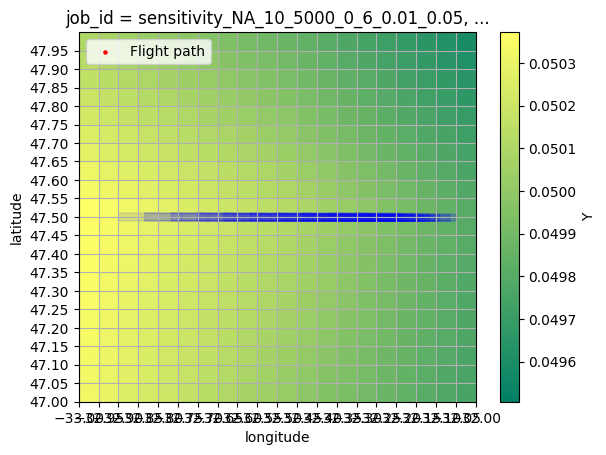

In [17]:
pp_gpat.plot_heatmap(params, fl_df, pl_df, chem_ds, ts=3*100, da="Y", property="NO", plot_fl=True, plot_pl=True)  

#chem_ds["emi"].sel(emi_species="NO").sel(time=time).plot()


In [18]:
vecmass, gridmass, mc = mc_test(params, fl_df, pl_df, chem_ds)

In [21]:
pd.set_option('display.max_rows', None)

gridmass

,NO,NO2,CO,HCHO,CH3CHO,C2H4,C3H6,C2H2,BENZENE
2022-01-20 13:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-01-20 13:02:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-01-20 13:04:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-01-20 13:06:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-01-20 13:08:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-01-20 13:10:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-01-20 13:12:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-01-20 13:14:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-01-20 13:16:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-01-20 13:18:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [ ]:
# # bg run conc time series plots
fig, ax = plt.subplots(4, 2, figsize=(10, 10))

# chem_ds = pp_gpat.filter_plume_cells(chem_ds)

chem_ds["Y"].sel(species_out="NO").values
# chem_ds = pp_gpat.calc_spatial_mean(chem_ds)


In [ ]:

# get time var
time = chem_ds["time"].values

# get month from time var
month = pd.to_datetime(time).month

# species to plot
NO = chem_ds["Y"].sel(species_out="NO").values
NO2 = chem_ds["Y"].sel(species_out="NO2").values
NOx = NO + NO2
O3 = chem_ds["Y"].sel(species_out="O3").values
OH = chem_ds["Y"].sel(species_out="OH").values
HO2 = chem_ds["Y"].sel(species_out="HO2").values
CO = chem_ds["Y"].sel(species_out="CO").values
CH4 = chem_ds["Y"].sel(species_out="CH4").values

NOy = pp_gpat.calc_NOy(chem_ds)
NOz = pp_gpat.calc_NOz(chem_ds)

pp_gpat.plot_line_plot(ax[0, 0], time, NO, 'NO', 'Time / days', 'Concentration / ppb') 
pp_gpat.plot_line_plot(ax[0, 1], time, NO2, 'NO2', 'Time / days', 'Concentration / ppb') 
pp_gpat.plot_line_plot(ax[1, 0], time, O3, 'O3', 'Time / days', 'Concentration / ppb')
pp_gpat.plot_line_plot(ax[1, 1], time, NOy, 'NOy', 'Time / days', 'Concentration / ppb')
pp_gpat.plot_line_plot(ax[2, 0], time, OH, 'OH', 'Time / days', 'Concentration / ppb')
pp_gpat.plot_line_plot(ax[2, 1], time, HO2, 'HO2', 'Time / days', 'Concentration / ppb')
pp_gpat.plot_line_plot(ax[3, 0], time, CO, 'CO', 'Time / days', 'Concentration / ppb')
pp_gpat.plot_line_plot(ax[3, 1], time, CH4, 'CH4', 'Time / days', 'Concentration / ppb')
fig.suptitle('Time series of species concentrations for background run NA Jan')
plt.tight_layout()
# plt.savefig(f"{outputs_dir}/plots/sensitivity_NA_Jan_concs_time_series.png")
plt.show()

In [12]:
# # bg run metric time series plots
# fig, ax = plt.subplots(3, 2, figsize=(10, 7.5))

# # get time var
# time = chem_ds["time"].values

# # get month from time var
# month = pd.to_datetime(time).month

# # species to plot
# NO = chem_ds["Y"].sel(species_out="NO").values
# NO2 = chem_ds["Y"].sel(species_out="NO2").values
# NOx = NO + NO2
# O3 = chem_ds["Y"].sel(species_out="O3").values
# OH = chem_ds["Y"].sel(species_out="OH").values
# HO2 = chem_ds["Y"].sel(species_out="HO2").values
# CO = chem_ds["Y"].sel(species_out="CO").values
# CH4 = chem_ds["Y"].sel(species_out="CH4").values
# T = chem_ds["air_temperature"].isel(time=0)
# M = chem_ds["M"].isel(time=0)

# NOy = pp_gpat.calc_NOy(chem_ds)
# NOz = pp_gpat.calc_NOz(chem_ds)

# NO2t = pp_gpat.calc_NO2t(chem_ds)
# O3_NOz = pp_gpat.calc_O3_NOz(chem_ds, NOz)
# HCHO_NO2 = pp_gpat.calc_HCHO_NO2(chem_ds)
# H2O2_HNO3 = pp_gpat.calc_H2O2_HNO3(chem_ds)
# alpha_CH3O2 = pp_gpat.calc_alpha_CH3O2(chem_ds) 

# pp_gpat.plot_line_plot(ax[0, 0], time, NOx, 'NOx', 'Time / days', 'Concentration / ppb')
# pp_gpat.plot_line_plot(ax[0, 1], time, NO2t, 'NO2 Threshold', 'Time / days', 'Concentration / ppb') 
# pp_gpat.plot_line_plot(ax[1, 0], time, O3_NOz, 'O3 / NOz', 'Time / days', '') 
# pp_gpat.plot_line_plot(ax[1, 1], time, HCHO_NO2, 'HCHO / NO2', 'Time / days', '')
# pp_gpat.plot_line_plot(ax[2, 0], time, H2O2_HNO3, 'H2O2 / HNO3', 'Time / days', '')
# pp_gpat.plot_line_plot(ax[2, 1], time, alpha_CH3O2, 'alpha CH3O2', 'Time / days', '')

# # ax[0,0].grid(True, which='both', linestyle='--', linewidth=0.5)
# fig.suptitle('Time series of NOx saturation metrics for background run NA Jan')
# plt.tight_layout()
# plt.savefig(f"{outputs_dir}/plots/bg_run_NA_Jan_metrics_time_series.png")
# plt.show()



In [13]:
# chem_da = []
# emi_da = []
# # Create a figure and axis for plotting
# fig, ax = plt.subplots(figsize=(10, 6))

# for job, ds in enumerate(chem_ds):
#     chem_ds[job] = chem_ds[job].assign_coords(species_out=chem_ds[job].attrs["species_out"])
#     chem_da.append(chem_ds[job]["Y"])

#     emi_da.append(chem_ds[job]["emi"])

#     chem_da_cell = chem_da[job].sel(level=chem_da[0].level[1], longitude=-32.9, latitude=47.1, method='nearest')
#     emi_da_cell = emi_da[job].sel(level=emi_da[0].level[1], longitude=-32.9, latitude=47.1, method='nearest')

#     NO_data = chem_da_cell.sel(species_out="NO")
#     NO2_data = chem_da_cell.sel(species_out="NO2")
#     O3_data = chem_da_cell.sel(species_out="O3")

#     NO_emi_data = emi_da_cell.sel(emi_species="NO")
#     NO2_emi_data = emi_da_cell.sel(emi_species="NO2")

#     # Plot the time series data
#     #NO_data.plot(ax=ax, label=f"NO {chem_da_cell['job_id'].values[0]}")
#     NO_data.plot(ax=ax, label=f"NO Emissions {emi_da_cell['job_id'].values[0]}")
#     NO_emi_data.plot(ax=ax, label=f"NO Emissions {emi_da_cell['job_id'].values[0]}")

# # Add labels and legend
# ax.set_xlabel('Time')
# ax.set_ylabel('Concentration')
# ax.set_title('Time Series of Species Concentration at Selected Cell')
# ax.legend()

# # plt.show()
# pd.set_option('display.max_rows', 500)
# NO_df = NO_data.to_dataframe()
# NO_df

# NO_data.max()


In [14]:

# chem_ds_stacked = chem_ds.stack(
#             {"cell": ["level", "longitude", "latitude"]}
#         )
# chem_ds_stacked = chem_ds_stacked.reset_index("cell")

# chem_ds_stacked
 

In [15]:

# max_emi_cell = chem_ds_stacked["emi"].mean(dim="time").argmax()#.item()
# print(max_emi_cell)
# # find cell that has max emissions averaged over time in it
# cell_chem_ds = chem_ds_stacked.sel(job_id=job_ids[0], cell=max_emi_cell)
# cell_chem_ds
# # Select the emissions for the specified species
# emi_data = cell_chem_ds["emi"].sel(emi_species="NO")
# chem_data = cell_chem_ds["Y"].sel(species_out="NO")
# emi_data.plot()
# chem_data.plot()

# # # Convert time and emi data to pandas Series
# # ts = 0
# # time_series = pd.Series(emi_data["time"].values)
# # emi_series = pd.Series(emi_data.values)

# # # Print time and emi values side by side
# # for time, emi in zip(time_series, emi_series):
# #     ts += 1
# #     print(f"TS: {ts}, Time: {time}, EMI: {emi}")

# for s, species in enumerate(chem_ds["species"].values):
#     print(chem_ds["bg_chem"].isel(level=1,latitude=0,longitude=0, species=s).values)



In [16]:
#anim_chem(job_ids[0], jobs_df, fl_df, pl_df, chem_ds[0], var1="emi", var2="NO", level=chem_da[0].level[1], resample_freq="2min")

In [17]:
# vecmass, gridmass, mc = mc_test(job_ids[0], jobs_df, fl_df, pl_df, chem_ds)
# mc

In [18]:
# path = '/user/work/kt16229/pycontrails_kt/pycontrails/models/gpat/'

# cell_chem_ds = boxm_test(path, job_ids[0], 0, chem_ds)

# # dj_data = cell_chem_ds["DJ"].sel(photol_coeffs=3)
# # dj_orig_data = cell_chem_ds["DJ_orig"].sel(photol_coeffs=3)
# # dj_data.plot()
# # dj_orig_data.plot()

# chem_data = cell_chem_ds["Y"].sel(species_out="NO")
# chem_orig_data = cell_chem_ds["Y_orig"].sel(species_out="NO")
# chem_data.plot()
# chem_orig_data.plot()
